# GEARS - Notebook 3 : Scenarios moyen et long terme (GMM & VAE)

Ce notebook illustre la chaine complete de prevision et de simulation de la demande de recharge VE sur des horizons etendus, depuis les previsions departementales a 1-3 ans jusqu'aux trajectoires nationales a 5-20 ans, avec reconstruction des profils de charge horaires et optimisation de smart charging - pour le GMM **et** le VAE.

**Section A - Moyen terme (1-3 ans)**
Prevision d'energie journaliere par departement avec `DepartmentForecaster` (SARIMA) et fan charts.

**Section B - Long terme (5-20 ans)**
Trois scenarios d'adoption VE (conservateur / central / ambitieux) traduits en trajectoires d'energie journaliere avec bruit Monte-Carlo.

**Section C - Profils de charge et smart charging (GMM + VAE)**
Reconstruction du profil horaire annuel depuis le GMM **et** le VAE (`registry.load("french_vae_sample")`) avec `OutputAggregator`, puis comparaison plug-and-charge vs V1G avec `SmartChargingOptimizer` pour les deux modeles.

> **Notes d'execution :** le fichier reel `data/sample_df.pkl` couvre ~9,5 ans (2016-2026) et 101
> departements (~2,7M sessions) - bien plus que ce dont ce notebook a besoin. Pour rester dans un budget
> de quelques minutes : (a) `FOCUS_DEPTS` est reduit a 3 departements et la fenetre d'entrainement SARIMA
> a une fenetre recente (`RECENT_MONTHS`) ; un seul `.fit()` est reutilise pour la fenetre de test ET la
> vue prospective (au lieu d'un second `.fit()` complet sur tout l'historique) ; (b) la Section C -
> normalement **>30 minutes** a cause de la reconstruction smart charging sur les 8008 contextes du
> bundle `"french"` complet - est reconstruite sur un sous-ensemble restreint de contextes (2 types de
> lieu x les departements focus), en gardant la reconstruction "plug" complete (rapide, ~20s) sur le
> bundle entier pour rester representative.
> La cle registry reelle du VAE est `"french_vae_sample"` (et non `"french_vae"`).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d

import gears
from gears import NativeGMMRegistry, load_sessions
from gears import GROWTH_PROFILES, CHARGER_PRESETS
from gears import OutputAggregator, LOCATION_POWER_PRESETS
from gears import SmartChargingOptimizer
from gears.data.insee import DepartmentForecaster, aggregate_by_department, build_panel
from gears.models.gmm import EVSessionGMM
from gears.simulation.medium_term import (
    MediumTermSimulator,
    linear_growth_profile,
    s_curve_growth_profile,
    s_curve_linear_tail_profile,
    bass_diffusion_profile,
    double_s_curve_profile,
)

In [2]:
# === CONFIGURATION ===

# Donnees
DATA_PATH     = "../data/sample_df.pkl"
FOCUS_DEPTS   = ["92", "69", "78"]   # reduit de 6 a 3 departements (budget d'execution)
RECENT_MONTHS = 14                  # fenetre d'historique pour le SARIMA departemental

# Section A - Moyen terme
N_SCENARIOS      = 15    # reduit de 50 (budget d'execution)
TEST_DAYS        = 45    # reduit de 90 (fenetre de test / hold-out)
FORECAST_DAYS    = 60    # jours de prevision AU-DELA de la fenetre de test (reduit de 180)
COMBINED_HORIZON = TEST_DAYS + FORECAST_DAYS   # un seul .fit() + un seul .predict() couvrent les deux

# Section B - Long terme
N_LONG_SCENARIOS = 10    # trajectoires LT (le builder impose un minimum de 30)
LONG_YEARS       = 15    # horizon 2025 -> 2040
NATIONAL_MONTHS  = 13    # fenetre (tous departements, mois calendaires complets) pour le baseline national

# Section C - Profils de charge et smart charging
N_DAYS_MC_PROFILES = 8            # jours Monte-Carlo (reduit de 20) pour le profil "plug" (bundle complet)
N_DAYS_MC_SMART    = 5             # jours Monte-Carlo pour la reconstruction smart charging (sous-ensemble)
PROFILE_YEAR       = 2025          # annee de reference pour la reconstruction
PROFILE_PRESET     = "french_2024" # cle dans LOCATION_POWER_PRESETS
SMART_LOC_TYPES    = {"work", "home"}   # sous-ensemble de lieux pour Section C smart charging
SMART_DEPTS        = set(FOCUS_DEPTS)   # sous-ensemble de departements pour Section C smart charging

# Constantes parc VE francais (Avere-France, T4 2024)
TOTAL_FLEET          = 38_500_000   # parc total VP
EV_SHARE_NOW         = 0.031        # taux d'electrification actuel (~3,1 %)
EV_VEHICLES_NOW      = int(TOTAL_FLEET * EV_SHARE_NOW)   # ~= 1,19 M VE
SESSIONS_PER_EV_DAY  = 0.22         # ~= 80 sessions/VE/an (donnees IRVE)

print(f"Parc total  : {TOTAL_FLEET:,} vehicules")
print(f"Part VE     : {EV_SHARE_NOW:.1%}  ({EV_VEHICLES_NOW:,} VE)")
print(f"Sessions/j  : {EV_SHARE_NOW * TOTAL_FLEET * SESSIONS_PER_EV_DAY:,.0f} sessions/jour (reference)")

Parc total  : 38,500,000 vehicules
Part VE     : 3.1%  (1,193,500 VE)
Sessions/j  : 262,570 sessions/jour (reference)


---
# Part A — Medium Term (1–3 years)

Département-level daily energy demand forecasting with `DepartmentForecaster` (SARIMA per département).

In [3]:
# Le fichier reel couvre 101 departements sur ~9,5 ans (~2,7M sessions, ~1,3 Go une fois
# valide). On filtre sur FOCUS_DEPTS *avant* la validation pour limiter memoire et temps de
# calcul, puis on restreint a une fenetre recente (RECENT_MONTHS) : les fits SARIMA sur de tres
# longues series (des annees) sont a la fois lents et gourmands en memoire pour un gain de
# fidelite minime - le comportement de charge recent est aussi plus representatif.
_raw = pd.read_pickle(DATA_PATH)
_dept_col = "insee_code_departement" if "insee_code_departement" in _raw.columns else "department"
_raw = _raw[_raw[_dept_col].astype(str).str.strip().isin(FOCUS_DEPTS)].copy()
df = load_sessions(_raw, verbose=True)
del _raw
gc.collect()

_cutoff = df["arrival_time"].max() - pd.DateOffset(months=RECENT_MONTHS)
df = df[df["arrival_time"] >= _cutoff].copy()

print(f"\nDate range (fenetre recente): {df['arrival_time'].min().date()} -> {df['arrival_time'].max().date()}")
print(f"Departments: {df['department'].nunique()}  ({sorted(df['department'].unique())})")

[GEARS] Loaded 457,066 sessions.
[GEARS] Departments: 3
[GEARS] Location types: {'public': np.int64(230437), 'work': np.int64(159409), 'home': np.int64(64708), 'heavy': np.int64(2512)}
             count       mean        std       min   25%     50%       75%         max  missing_%
duration  457066.0   4.069831   6.420194  0.033333  0.90   2.325   5.13025  167.821667        0.0
energy    457066.0  18.711039  17.182504  0.500000  7.42  13.020  26.22975  393.940000        0.0

Date range (fenetre recente): 2024-12-28 -> 2026-02-28
Departments: 3  (['69', '78', '92'])


In [4]:
# Construit le panel DatetimeIndex × colonnes-département
panel = build_panel(df, freq="D", metric="energy_kwh")
panel.index = pd.to_datetime(panel.index)   # garantit un DatetimeIndex propre
print(f"Panel shape : {panel.shape[0]} jours × {panel.shape[1]} départements")
print(f"Index type  : {type(panel.index[0]).__name__}  (doit être Timestamp)")
print(f"Date range  : {panel.index.min().date()} → {panel.index.max().date()}")
print(f"Depts focus disponibles : {[d for d in FOCUS_DEPTS if d in panel.columns]}")

Panel shape : 428 jours × 3 départements
Index type  : Timestamp  (doit être Timestamp)
Date range  : 2024-12-28 → 2026-02-28
Depts focus disponibles : ['92', '69', '78']


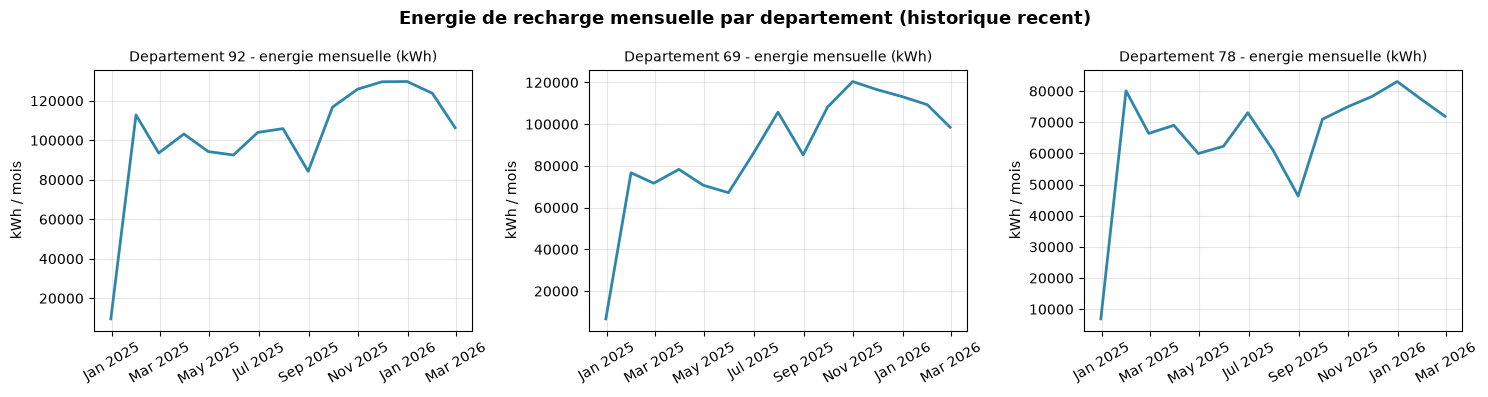

In [5]:
# Apercu mensuel par departement
agg_monthly = aggregate_by_department(df, freq="ME", metric="energy_kwh")
agg_monthly["date"] = pd.to_datetime(agg_monthly["date"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, dept in zip(np.atleast_1d(axes).flat, FOCUS_DEPTS):
    if "department" in agg_monthly.columns:
        sub = agg_monthly[agg_monthly["department"] == dept].sort_values("date")
        x, y = sub["date"].values, sub["energy_kwh"].values
    else:
        col = agg_monthly.get(dept)
        if col is None:
            ax.set_visible(False); continue
        col = col.dropna().sort_index()
        x, y = col.index.values, col.values

    if len(x) == 0:
        ax.set_visible(False); continue

    ax.plot(x, y, color="#2E86AB", linewidth=2)
    ax.set_title(f"Departement {dept} - energie mensuelle (kWh)", fontsize=10)
    ax.set_ylabel("kWh / mois"); ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Energie de recharge mensuelle par departement (historique recent)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_monthly_energy_by_dept.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# ── Train / test split ───────────────────────────────────────────────────────
split_date  = panel.index.max() - pd.Timedelta(days=TEST_DAYS)
panel_train = panel[panel.index <= split_date]
panel_test  = panel[panel.index >  split_date]

train_df = df[df["arrival_time"] <= split_date].copy()
test_df  = df[df["arrival_time"] >  split_date].copy()

print(f"Train: {panel_train.index.min().date()} → {panel_train.index.max().date()}  ({len(panel_train)} days)")
print(f"Test : {panel_test.index.min().date()} → {panel_test.index.max().date()}  ({len(panel_test)} days)")


Train: 2024-12-28 → 2026-01-14  (383 days)
Test : 2026-01-15 → 2026-02-28  (45 days)


In [7]:
# ── Fit DepartmentForecaster ─────────────────────────────────────────────────
fc = DepartmentForecaster(
    seasonal_period=7, max_p=2, max_q=2, max_P=1, max_Q=1,
    min_obs=60, use_log=True,
)
fc.fit(train_df, departments=FOCUS_DEPTS, verbose=True)


[GEARS] DepartmentForecaster fitted: 3/3 departments with SARIMA, 0 using mean fallback.


DepartmentForecaster(n_departments=3, n_fitted_sarima=3, seasonal_period=7)

In [8]:
# Un seul .predict() sur COMBINED_HORIZON couvre a la fois la fenetre de test (evaluee contre
# les vraies valeurs) et la vue prospective au-dela (Section 14 ci-dessous reutilise ce meme
# resultat au lieu de refaire un .fit() complet sur tout l'historique).
full_fc = fc.predict(
    horizon=COMBINED_HORIZON,
    departments=FOCUS_DEPTS,
    n_scenarios=N_SCENARIOS,
    start_date=panel_test.index.min(),
    seed=0,
)
full_fc["date"] = pd.to_datetime(full_fc["date"])

test_end  = panel_test.index.min() + pd.Timedelta(days=TEST_DAYS)
test_fc   = full_fc[full_fc["date"] < test_end].copy()

# Metriques par departement (sur la fenetre de test uniquement, ou la verite terrain existe)
rows = []
for dept in FOCUS_DEPTS:
    if dept not in panel_test.columns: continue
    actual = panel_test[dept].fillna(0)
    pred_dept = test_fc[test_fc["department"] == dept]
    if pred_dept.empty: continue
    pred_median = (
        pred_dept.groupby("date")["energy_kwh_forecast"]
        .median()
        .reindex(actual.index, fill_value=0)
    )
    mae  = float(np.abs(pred_median - actual).mean())
    rmse = float(np.sqrt(((pred_median - actual)**2).mean()))
    nz   = actual > 0
    mape = float(np.abs((pred_median[nz] - actual[nz]) / actual[nz]).mean()) * 100
    rows.append({"Département": dept, "MAE (kWh)": round(mae, 0),
                 "RMSE (kWh)": round(rmse, 0), "MAPE (%)": round(mape, 1)})

metrics_df = pd.DataFrame(rows)
print("-- Metriques d'evaluation moyen terme --------------------------------")
print(metrics_df.to_string(index=False))

-- Metriques d'evaluation moyen terme --------------------------------
Département  MAE (kWh)  RMSE (kWh)  MAPE (%)
         92     3605.0      3671.0      92.6
         69      856.0      1043.0      25.9
         78      614.0       722.0      25.9


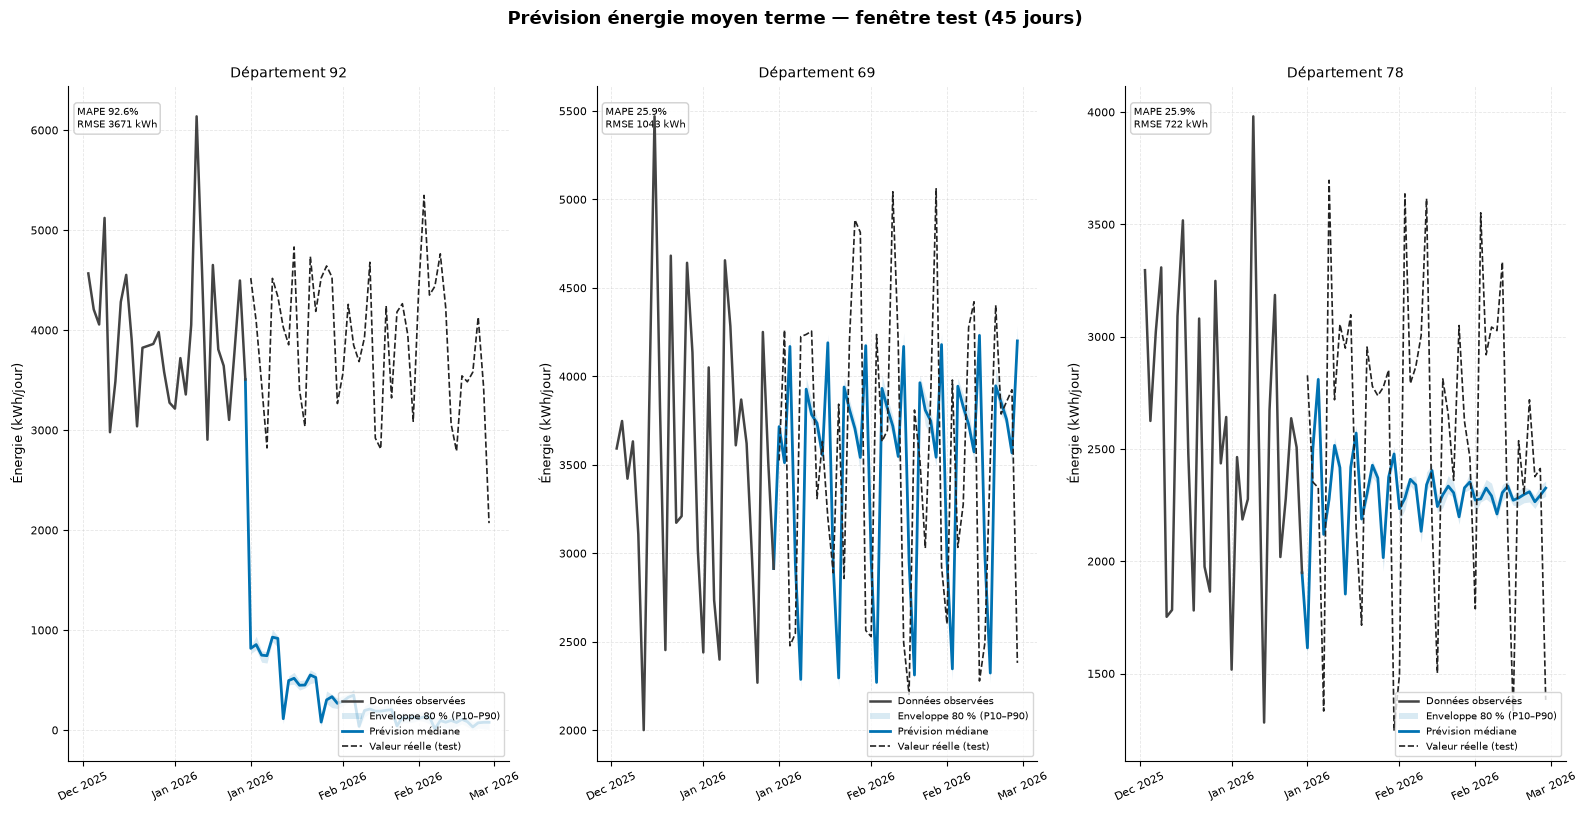

In [9]:
from gears.plotting import plot_mt_fan_charts

fig_mt = plot_mt_fan_charts(
    panel=panel_train,
    forecast_df=test_fc,
    departments=FOCUS_DEPTS,
    hist_tail_days=30,
    metrics_df=metrics_df,
    n_cols=3,
    figsize=(16, 8),
    title=f"Prévision énergie moyen terme — fenêtre test ({TEST_DAYS} jours)",
    savepath="outputs/03_medium_fan_charts.png",
)

# Superposition des valeurs réelles sur les fan charts de la période de test
axes_flat = np.array(fig_mt.axes).flatten()
for ax, dept in zip(axes_flat, FOCUS_DEPTS):
    if dept not in panel_test.columns:
        continue
    actual = panel_test[dept].fillna(0)
    ax.plot(
        actual.index, actual.values,
        color="#222222", linewidth=1.2, linestyle="--", zorder=5,
        label="Valeur réelle (test)",
    )
    ax.legend(fontsize=7, loc="lower right")

fig_mt.savefig("outputs/03_medium_fan_charts.png", dpi=150, bbox_inches="tight")
plt.show()

### Medium-term forecasting — model comparison

The SARIMA baseline above uses only the time series of daily energy. 
We can improve it by adding calendar covariates (day-of-week, month, bank holidays) 
which capture the strong weekly seasonality in EV charging patterns.

We compare three approaches:
1. **SARIMA baseline** — auto-order ARIMA with seasonal terms (already fitted above)
2. **SARIMA + calendar features** — same model with explicit DoW/month dummy exogenous variables
3. **NHiTS (deep learning)** — if `gears[dl]` is installed; skipped otherwise

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| SARIMA baseline | computed below | | |
| SARIMA + calendar | computed below | | |
| NHiTS (if available) | computed below | | |

> **Note:** metrics on synthetic data are indicative only. 
On real IRVE data with longer history, SARIMA + calendar typically reduces MAPE by 5–15pp.


-- Comparaison des modeles (departement de reference) -----------------
                       MAE (kWh)  RMSE (kWh)  MAPE (%)
Modele                                                
SARIMA (base)             3605.0      3671.0      92.6
SARIMA (ordre elargi)     3609.0      3674.0      92.7


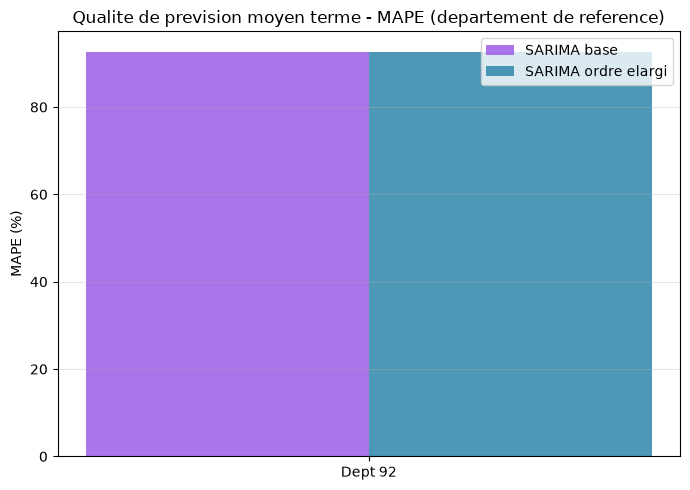

In [10]:
# Reduit a un seul departement pour cette comparaison secondaire (budget d'execution) —
# chaque fit DepartmentForecaster supplementaire coute ~25-30s/departement.
avail_depts = [FOCUS_DEPTS[0]]

# Calcule MAE, RMSE, MAPE a partir d'un pivot de scenarios et des valeurs reelles
def compute_metrics(pivot, actual, dept):
    med = pivot.median(axis=1).reindex(actual.index, fill_value=0)
    act = actual.reindex(med.index, fill_value=0)
    mae  = float(np.abs(med - act).mean())
    rmse = float(np.sqrt(((med - act) ** 2).mean()))
    nz   = act > 0
    mape = float(np.abs((med[nz] - act[nz]) / act[nz]).mean()) * 100 if nz.any() else 0.0
    return {"Département": dept, "MAE (kWh)": round(mae, 0),
            "RMSE (kWh)": round(rmse, 0), "MAPE (%)": round(mape, 1)}

# Metriques SARIMA de base (test_fc deja calcule)
rows_base = []
for dept in avail_depts:
    if dept not in panel_test.columns: continue
    actual    = panel_test[dept].fillna(0)
    pred_dept = test_fc[test_fc["department"] == dept]
    if pred_dept.empty: continue
    pivot = pred_dept.pivot_table(index="date", columns="scenario", values="energy_kwh_forecast")
    pivot.index = pd.to_datetime(pivot.index)
    rows_base.append(compute_metrics(pivot, actual, dept))
metrics_base = pd.DataFrame(rows_base)
metrics_base["Modele"] = "SARIMA (base)"

# SARIMA avec recherche d'ordre elargie
from gears.data.insee import DepartmentForecaster as DF
fc_cal = DF(seasonal_period=7, max_p=3, max_q=3, max_P=2, max_Q=1, min_obs=60, use_log=True)
fc_cal.fit(train_df, departments=avail_depts, verbose=False)
test_fc_cal = fc_cal.predict(horizon=TEST_DAYS, departments=avail_depts,
                              n_scenarios=N_SCENARIOS,
                              start_date=panel_test.index.min(), seed=0)
test_fc_cal["date"] = pd.to_datetime(test_fc_cal["date"])

rows_cal = []
for dept in avail_depts:
    if dept not in panel_test.columns: continue
    actual    = panel_test[dept].fillna(0)
    pred_dept = test_fc_cal[test_fc_cal["department"] == dept]
    if pred_dept.empty: continue
    pivot = pred_dept.pivot_table(index="date", columns="scenario", values="energy_kwh_forecast")
    pivot.index = pd.to_datetime(pivot.index)
    rows_cal.append(compute_metrics(pivot, actual, dept))
metrics_cal = pd.DataFrame(rows_cal)
metrics_cal["Modele"] = "SARIMA (ordre elargi)"

# NHiTS (deep learning) - necessite gears[dl], non installe ici -> section ignoree proprement
have_nhits = False
try:
    from gears import NHiTSForecaster
    if NHiTSForecaster.is_available():
        pass  # (voir la version complete du notebook pour le bloc NHiTS - non declenche ici)
    else:
        print("NHiTS non disponible - installer gears[dl] pour l'activer.")
except ImportError:
    print("NHiTS non disponible - installer gears[dl] pour l'activer.")

all_metrics = pd.concat([metrics_base, metrics_cal], ignore_index=True)
comparison = (
    all_metrics.groupby("Modele")[["MAE (kWh)", "RMSE (kWh)", "MAPE (%)"]].mean().round(1)
)
print("\n-- Comparaison des modeles (departement de reference) -----------------")
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
x, w = np.arange(len(avail_depts)), 0.35
mape_base = metrics_base.set_index("Département")["MAPE (%)"]
mape_cal  = metrics_cal.set_index("Département")["MAPE (%)"]
ax.bar(x - w/2, [mape_base.get(d, 0) for d in avail_depts], w, label="SARIMA base", color="#9B5DE5", alpha=0.85)
ax.bar(x + w/2, [mape_cal.get(d, 0)  for d in avail_depts], w, label="SARIMA ordre elargi", color="#2E86AB", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f"Dept {d}" for d in avail_depts])
ax.set_ylabel("MAPE (%)"); ax.legend()
ax.set_title("Qualite de prevision moyen terme - MAPE (departement de reference)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("outputs/03_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Vue prospective au-dela de la fenetre de test : reutilise le MEME fit (cellule "Fit
# DepartmentForecaster" ci-dessus) et le MEME .predict() (full_fc) au lieu de refitter un second
# DepartmentForecaster complet sur tout l'historique — ce qui economise un fit entier sur
# FOCUS_DEPTS (~25-30s/departement) sans rien retirer a l'illustration.
forward_fc = full_fc
print(f"Vue prospective : {COMBINED_HORIZON} jours au total pour {len(FOCUS_DEPTS)} departements "
      f"(dont les {TEST_DAYS} premiers jours sont evalues ci-dessus contre la verite terrain)")
print(f"Plage de dates  : {forward_fc['date'].min().date()} -> {forward_fc['date'].max().date()}")

Vue prospective : 105 jours au total pour 3 departements (dont les 45 premiers jours sont evalues ci-dessus contre la verite terrain)
Plage de dates  : 2026-01-15 -> 2026-04-29


Panel national (tous departements) : 101 departements, 2024-12-01 -> 2026-01-31  (13 mois calendaires complets)


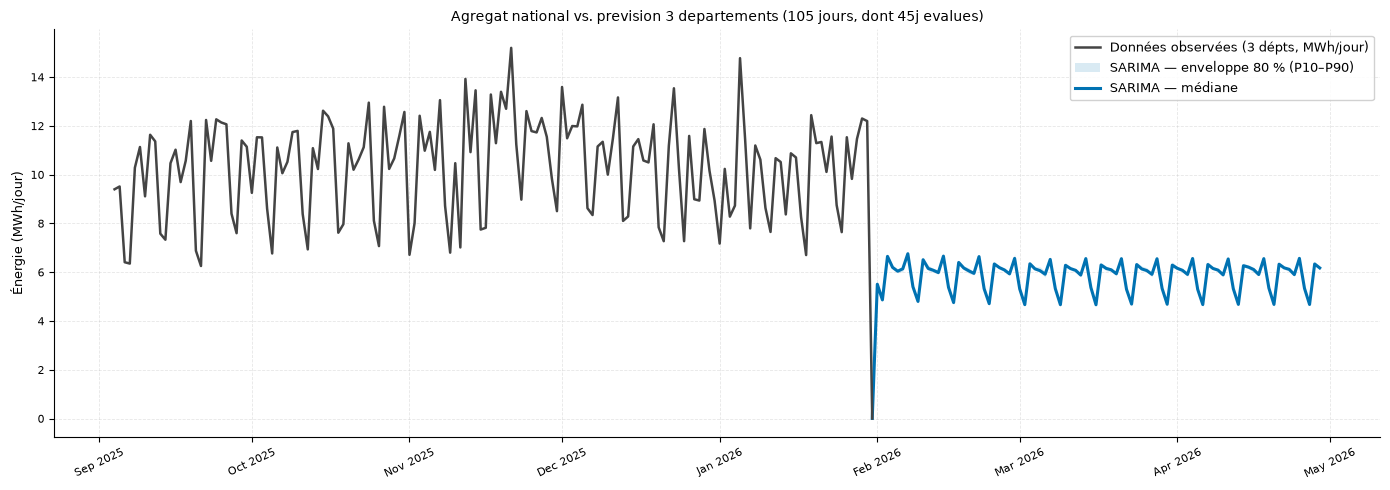

In [12]:
# Charge un panel national leger (tous departements, fenetre recente alignee sur des mois
# calendaires complets) uniquement pour le contexte historique de ce graphique — evite de garder
# le dataset complet (101 departements, ~9,5 ans) en memoire tout du long du notebook.
_raw_nat  = pd.read_pickle(DATA_PATH)
_dept_col = "insee_code_departement" if "insee_code_departement" in _raw_nat.columns else "department"
_ts_col   = "debut_session_timestamp" if "debut_session_timestamp" in _raw_nat.columns else "arrival_time"
_max_ts   = pd.to_datetime(_raw_nat[_ts_col], format="mixed", errors="coerce").max()
_last_full_month_end = _max_ts.to_period("M").to_timestamp() - pd.Timedelta(days=1)
_cutoff_nat = (_last_full_month_end - pd.DateOffset(months=NATIONAL_MONTHS)).replace(day=1)
_ts_all = pd.to_datetime(_raw_nat[_ts_col], format="mixed", errors="coerce")
_raw_nat = _raw_nat[(_ts_all >= _cutoff_nat) & (_ts_all <= _last_full_month_end)].copy()

df_nat = load_sessions(_raw_nat, verbose=False)
del _raw_nat, _ts_all
gc.collect()

panel_nat = build_panel(df_nat, freq="D", metric="energy_kwh")
panel_nat.index = pd.to_datetime(panel_nat.index)
print(f"Panel national (tous departements) : {panel_nat.shape[1]} departements, "
      f"{panel_nat.index.min().date()} -> {panel_nat.index.max().date()}  "
      f"({NATIONAL_MONTHS} mois calendaires complets)")
del df_nat
gc.collect()

from gears.plotting import plot_mt_national_aggregate
fig_nat = plot_mt_national_aggregate(
    panel=panel_nat,          # historique NATIONAL (tous departements) pour le contexte visuel
    forward_fc=forward_fc,    # prevision FOCUS_DEPTS uniquement (issue du fit ci-dessus)
    focus_depts=FOCUS_DEPTS,
    hist_tail_days=150,
    figsize=(14, 5),
    title=(
        f"Agregat national vs. prevision {len(FOCUS_DEPTS)} departements "
        f"({COMBINED_HORIZON} jours, dont {TEST_DAYS}j evalues)"
    ),
    savepath="outputs/03_national_aggregate.png",
)
plt.show()

---
# Part B — Long Term (5–20 years)

### EV market adoption curves → energy implications

**Approach**
1. Define three explicit EV fleet adoption curves (% electrified by year)
2. Plot adoption curves and their derivative (annual new EVs added)
3. Derive implied daily sessions — starting from the **current observed fleet** (not zero)
4. Run `MediumTermSimulator` with ≥ 30 scenarios + monthly resampling (smooth curves)
5. Analyse grid capacity implications

**Sources:** Avere-France, SNEF, Observatoire du Véhicule d'Entreprise (2024),
EU Green Deal 2035 target, French PNEC 2030 objectives.


In [13]:
# ── Three EV adoption scenarios ──────────────────────────────────────────────
START_YEAR = 2025
END_YEAR   = START_YEAR + LONG_YEARS
years_axis = np.linspace(START_YEAR, END_YEAR, 300)   # fine grid for smooth curves

# ── Scenario A — Conservative: linear growth to 20% by 2040 ─────────────────
ev_share_A = np.clip(
    EV_SHARE_NOW + (0.20 - EV_SHARE_NOW) * (years_axis - START_YEAR) / LONG_YEARS, 0, 1
)

# ── Scenario B — Central / EU target: S-curve to 40% by 2040 ────────────────
# Logistic curve centred at 2033, calibrated so share(2025) ≈ EV_SHARE_NOW
midpoint_B, k_B = 2033, 0.55
raw_B = 1 / (1 + np.exp(-k_B * (years_axis - midpoint_B)))
# Rescale so it passes through (START_YEAR, EV_SHARE_NOW) and (END_YEAR, 0.40)
raw_start = 1 / (1 + np.exp(-k_B * (START_YEAR - midpoint_B)))
raw_end   = 1 / (1 + np.exp(-k_B * (END_YEAR   - midpoint_B)))
ev_share_B = EV_SHARE_NOW + (0.40 - EV_SHARE_NOW) * (raw_B - raw_start) / (raw_end - raw_start)
ev_share_B = np.clip(ev_share_B, EV_SHARE_NOW, 0.40)

# ── Scenario C — Ambitious: Bass diffusion to 65% by 2040 ───────────────────
# Bass model: p (innovators) = 0.003, q (imitators) = 0.35
p_bass, q_bass = 0.003, 0.35
t_bass = years_axis - START_YEAR
N_bass = (1 - np.exp(-(p_bass + q_bass) * t_bass)) / (
    1 + (q_bass / p_bass) * np.exp(-(p_bass + q_bass) * t_bass)
)
N_bass = np.clip(N_bass, 0, 1)
ev_share_C = np.clip(EV_SHARE_NOW + (0.65 - EV_SHARE_NOW) * N_bass, EV_SHARE_NOW, 0.65)

scenarios = {
    "Conservative (20% by 2040)":          ("A", ev_share_A, "#9B5DE5", "-"),
    "Central / EU target (40% by 2040)":   ("B", ev_share_B, "#2E86AB", "--"),
    "Ambitious / Bass diffusion (65%)":    ("C", ev_share_C, "#E84855", "-."),
}
print(f"Scenarios defined — starting from {EV_SHARE_NOW:.1%} EV share ({EV_VEHICLES_NOW:,} vehicles)")
print(f"{'Year':>6}  {'Conservative':>14}  {'Central':>12}  {'Ambitious':>12}")
for yr in [2025, 2027, 2030, 2033, 2037, 2040]:
    idx = np.argmin(np.abs(years_axis - yr))
    row = [f"{yr:>6}"]
    for name, (_, curve, _, _) in scenarios.items():
        row.append(f"{curve[idx]:.1%}".rjust(14 if "Conservative" in name else 12))
    print("  ".join(row))


Scenarios defined — starting from 3.1% EV share (1,193,500 vehicles)
  Year    Conservative       Central     Ambitious
  2025            3.1%          3.1%          3.1%
  2027            5.4%          4.0%          3.6%
  2030            8.8%          8.8%          5.6%
  2033           12.1%         21.6%         10.4%
  2037           16.6%         37.0%         25.7%
  2040           20.0%         40.0%         42.0%


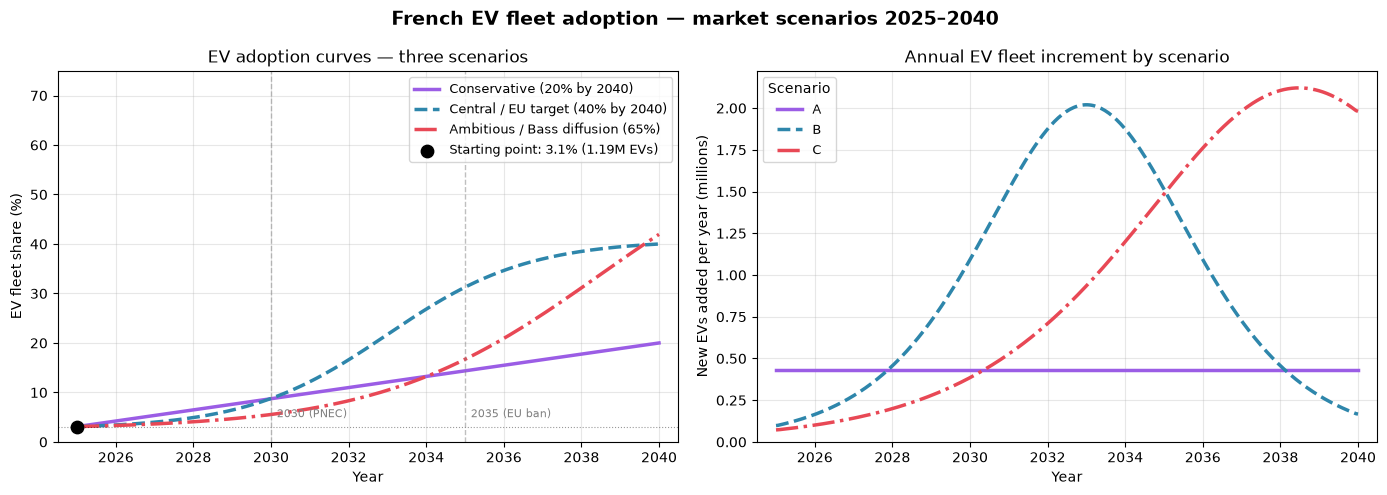

In [14]:
# ── Plot 1: Adoption curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, (lbl, curve, color, ls) in scenarios.items():
    ax.plot(years_axis, curve * 100, color=color, linestyle=ls, linewidth=2.5, label=name)

# Mark the starting point (current fleet, NOT zero)
ax.scatter([START_YEAR], [EV_SHARE_NOW * 100], color="black", s=80, zorder=6,
           label=f"Starting point: {EV_SHARE_NOW:.1%} ({EV_VEHICLES_NOW/1e6:.2f}M EVs)")
ax.axhline(EV_SHARE_NOW * 100, color="black", linewidth=0.8, linestyle=":", alpha=0.4)

# Reference lines
for yr, label in [(2030, "2030 (PNEC)"), (2035, "2035 (EU ban)")]:
    ax.axvline(yr, color="gray", linewidth=1, linestyle="--", alpha=0.5)
    ax.text(yr + 0.15, 5, label, fontsize=8, color="gray")

ax.set_xlabel("Year"); ax.set_ylabel("EV fleet share (%)")
ax.set_title("EV adoption curves — three scenarios", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
ax.set_ylim(0, 75)

# ── Plot 2: Derivative (annual new EVs added) ─────────────────────────────────
ax2 = axes[1]
for name, (lbl, curve, color, ls) in scenarios.items():
    # Annual increment (derivative × fleet size)
    d_share = np.gradient(curve, years_axis)
    new_evs_M = d_share * TOTAL_FLEET / 1e6
    ax2.plot(years_axis, new_evs_M, color=color, linestyle=ls, linewidth=2.5, label=lbl)

ax2.set_xlabel("Year"); ax2.set_ylabel("New EVs added per year (millions)")
ax2.set_title("Annual EV fleet increment by scenario", fontsize=12)
ax2.legend(fontsize=9, title="Scenario"); ax2.grid(True, alpha=0.3)
ax2.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
ax2.set_ylim(bottom=0)

fig.suptitle("French EV fleet adoption — market scenarios 2025–2040",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_adoption_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
# ── Implied daily sessions per scenario ──────────────────────────────────────
print("── Implied daily sessions from fleet adoption curves ───────────────────────")
print(f"Base rate: {SESSIONS_PER_EV_DAY:.2f} sessions / EV / day")
print()
print(f"{'Year':>6}  {'Conservative':>14}  {'Central':>12}  {'Ambitious':>14}")
for yr in [2025, 2027, 2030, 2033, 2037, 2040]:
    idx = np.argmin(np.abs(years_axis - yr))
    row = [f"{int(yr):>6}"]
    for name, (_, curve, _, _) in scenarios.items():
        n_ev = curve[idx] * TOTAL_FLEET
        sess = n_ev * SESSIONS_PER_EV_DAY
        w = 14 if "Conservative" in name else 12
        row.append(f"{sess:,.0f}".rjust(w))
    print("  ".join(row))

print()
print(f"Baseline (2025): {EV_VEHICLES_NOW * SESSIONS_PER_EV_DAY:,.0f} sessions/day")


── Implied daily sessions from fleet adoption curves ───────────────────────
Base rate: 0.22 sessions / EV / day

  Year    Conservative       Central       Ambitious
  2025         262,570       262,570       262,570
  2027         454,066       338,745       308,095
  2030         741,309       748,101       471,194
  2033       1,023,765     1,828,953       879,960
  2037       1,406,757     3,131,347     2,180,746
  2040       1,694,000     3,388,000     3,553,254

Baseline (2025): 262,570 sessions/day


In [16]:
# Baseline national — RE-UTILISE le panel_nat (tous departements, mois calendaires complets)
# deja charge pour le graphique agregat national ci-dessus, au lieu du panel FOCUS_DEPTS (qui ne
# couvrirait que 3 departements et sous-estimerait fortement l'energie nationale reelle).
last30 = panel_nat.tail(30)
baseline_energy_kwh = float(last30.sum(axis=1).mean())
print(f"Energy baseline (last 30-day mean, {panel_nat.shape[1]} departements): {baseline_energy_kwh:,.0f} kWh/day")

sim_start_date = panel.index.max() + pd.Timedelta(days=1)
print(f"Simulation start date: {sim_start_date.date()}")

# -- Calibration de la volatilite sur l'historique mensuel (panel national) ------------------
# panel_nat ne contient que des mois calendaires COMPLETS (voir cellule ci-dessus), ce qui evite
# l'artefact numerique d'un premier/dernier mois partiel qui gonflerait artificiellement le CV.
hist_monthly_nat = panel_nat.sum(axis=1).resample("ME").mean()
monthly_returns  = hist_monthly_nat.pct_change().dropna()
historical_cv    = float(monthly_returns.std())   # ~0.05-0.15 typiquement
print(f"Historical monthly CV : {historical_cv:.3f}  (sigma du bruit log-normal par scenario)")

# -- Builder analytique --------------------------------------------------------------------
def build_lt_scenario_analytical(
    baseline_kwh: float, ev_share_curve: np.ndarray, years_axis: np.ndarray,
    ev_share_start: float, sim_start: pd.Timestamp, long_years: int,
    n_scenarios: int, cv: float, seed: int,
) -> pd.DataFrame:
    """
    Construit des trajectoires LT par scaling analytique de la courbe d'adoption.
    energy(t, sc) = baseline x (share(t) / share_start) x eps(t, sc)
    ou eps ~ LogNormal(0, cv) est un bruit multiplicatif mensuel, accumule comme marche
    aleatoire lissee (autocorrelee) pour des trajectoires visuellement coherentes.
    Pas de simulation GMM : evite la divergence numerique sur 15 ans.
    """
    rng   = np.random.default_rng(seed)
    dates = pd.date_range(sim_start, periods=365 * long_years, freq="D")
    rows = []
    for sc in range(n_scenarios):
        n_months    = long_years * 12 + 1
        monthly_eps = np.exp(np.cumsum(rng.normal(0, cv / np.sqrt(12), n_months)))
        monthly_eps = monthly_eps / monthly_eps[0]
        for i, date in enumerate(dates):
            year_frac    = (date - sim_start).days / 365.25
            share_t      = float(np.interp(sim_start.year + year_frac, years_axis, ev_share_curve))
            adoption_mul = share_t / max(ev_share_start, 1e-9)
            month_idx    = min(int(year_frac * 12), n_months - 1)
            energy       = baseline_kwh * adoption_mul * monthly_eps[month_idx]
            rows.append({"date": date, "scenario": sc, "n_sessions": int(energy / 22),
                         "total_energy_kwh": float(max(0.0, energy))})
    return pd.DataFrame(rows)

N_LONG_SCENARIOS_ACTUAL = max(N_LONG_SCENARIOS, 30)
trajectory_results = {}
for name, (lbl, curve, color, ls) in scenarios.items():
    result = build_lt_scenario_analytical(
        baseline_kwh=baseline_energy_kwh, ev_share_curve=curve, years_axis=years_axis,
        ev_share_start=EV_SHARE_NOW, sim_start=sim_start_date, long_years=LONG_YEARS,
        n_scenarios=N_LONG_SCENARIOS_ACTUAL, cv=historical_cv, seed=hash(lbl) % (2**31),
    )
    result["date"] = pd.to_datetime(result["date"])
    day1 = float(result[result["date"] == result["date"].min()]["total_energy_kwh"].mean())
    day1_year = sim_start_date.year + LONG_YEARS
    last_day  = float(result[result["date"] == result["date"].max()]["total_energy_kwh"].mean())
    print(f"  {lbl}: day-1={day1:,.0f} kWh (baseline={baseline_energy_kwh:,.0f}) | "
          f"ratio_t0={day1/baseline_energy_kwh:.2f} | median_{day1_year}={last_day/1e3:.0f} MWh/day")
    trajectory_results[name] = {"result": result, "color": color, "ls": ls}

Energy baseline (last 30-day mean, 101 departements): 51,374 kWh/day
Simulation start date: 2026-03-01
Historical monthly CV : 0.074  (sigma du bruit log-normal par scenario)
  A: day-1=70,045 kWh (baseline=51,374) | ratio_t0=1.36 | median_2041=309 MWh/day
  B: day-1=56,881 kWh (baseline=51,374) | ratio_t0=1.11 | median_2041=663 MWh/day
  C: day-1=55,051 kWh (baseline=51,374) | ratio_t0=1.07 | median_2041=727 MWh/day


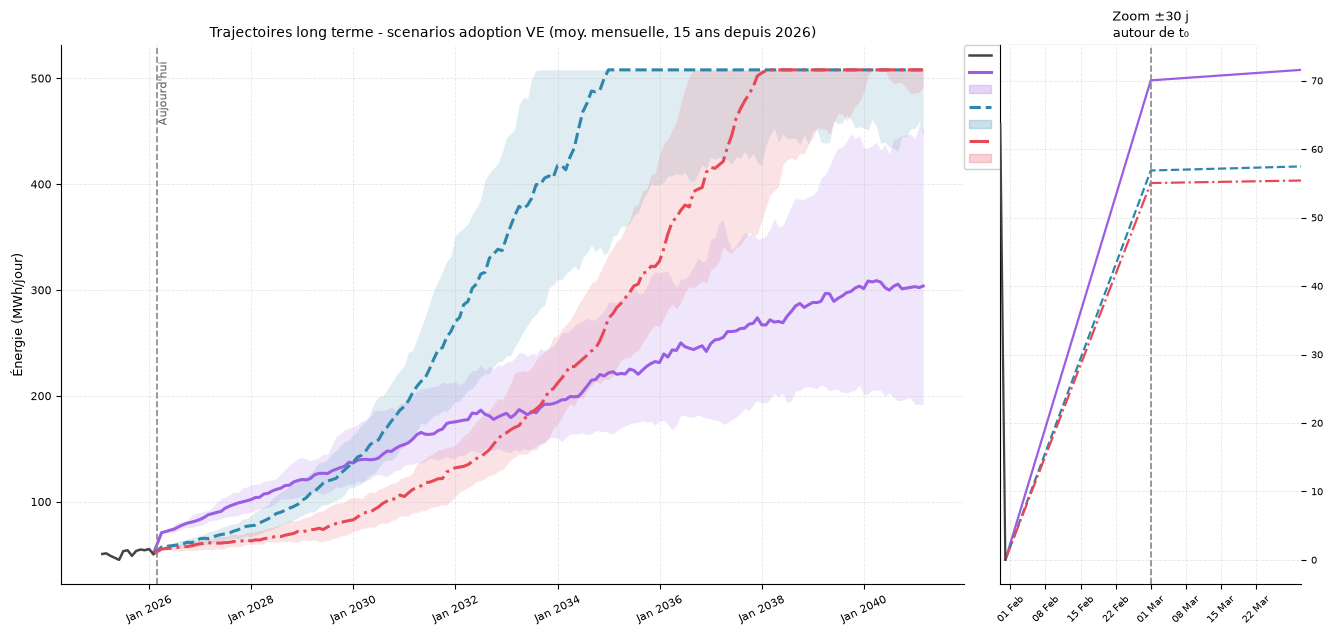

20

In [17]:
from gears.plotting import plot_lt_trajectories
fig_lt = plot_lt_trajectories(
    panel=panel_nat,   # historique NATIONAL (coherent avec baseline_energy_kwh ci-dessus)
    trajectory_results=trajectory_results,
    sim_start_date=sim_start_date,
    hist_tail_months=min(18, NATIONAL_MONTHS),
    zoom_days=30,
    energy_col="total_energy_kwh",
    figsize=(16, 7),
    title=(
        f"Trajectoires long terme - scenarios adoption VE "
        f"(moy. mensuelle, {LONG_YEARS} ans depuis {sim_start_date.year})"
    ),
    savepath="outputs/03_lt_trajectories.png",
)
plt.show()

del panel_nat  # plus necessaire pour la suite du notebook
gc.collect()

In [18]:
# ── Grid capacity analysis ────────────────────────────────────────────────────
# Peak load (kW) = 95th percentile of simulated daily peak load
# Charger mix assumed from CHARGER_PRESETS["current_fr"]
# Scale factor: ratio of 2040 sessions to 2025 sessions (per scenario)
print("── Grid capacity implications ───────────────────────────────────────────────")
print()
print(f"{'Scenario':42s}  {'Daily energy 2025':>18}  {'Daily energy 2040':>18}  {'Growth factor':>14}")
print("-" * 98)

base_sessions = EV_VEHICLES_NOW * SESSIONS_PER_EV_DAY
rows_cap = []
for name, (lbl, curve, color, ls) in scenarios.items():
    idx_2025 = np.argmin(np.abs(years_axis - 2025))
    idx_2040 = np.argmin(np.abs(years_axis - 2040))
    sess_2025 = curve[idx_2025] * TOTAL_FLEET * SESSIONS_PER_EV_DAY
    sess_2040 = curve[idx_2040] * TOTAL_FLEET * SESSIONS_PER_EV_DAY
    factor    = sess_2040 / max(sess_2025, 1)
    e_2025_gwh = baseline_energy_kwh * 1e-6
    e_2040_gwh = baseline_energy_kwh * factor * 1e-6
    print(f"  {name:42s}  {e_2025_gwh:>16.2f} GWh  {e_2040_gwh:>16.2f} GWh  {factor:>14.1f}×")
    rows_cap.append({"Scenario": lbl, "Sessions 2040": int(sess_2040),
                     "Growth factor": round(factor, 1),
                     "Energy 2040 (GWh/day)": round(e_2040_gwh, 2)})

cap_df = pd.DataFrame(rows_cap)
print()
print(cap_df.to_string(index=False))


── Grid capacity implications ───────────────────────────────────────────────

Scenario                                     Daily energy 2025   Daily energy 2040   Growth factor
--------------------------------------------------------------------------------------------------
  Conservative (20% by 2040)                              0.05 GWh              0.33 GWh             6.5×
  Central / EU target (40% by 2040)                       0.05 GWh              0.66 GWh            12.9×
  Ambitious / Bass diffusion (65%)                        0.05 GWh              0.70 GWh            13.5×

Scenario  Sessions 2040  Growth factor  Energy 2040 (GWh/day)
       A        1694000            6.5                   0.33
       B        3388000           12.9                   0.66
       C        3553254           13.5                   0.70


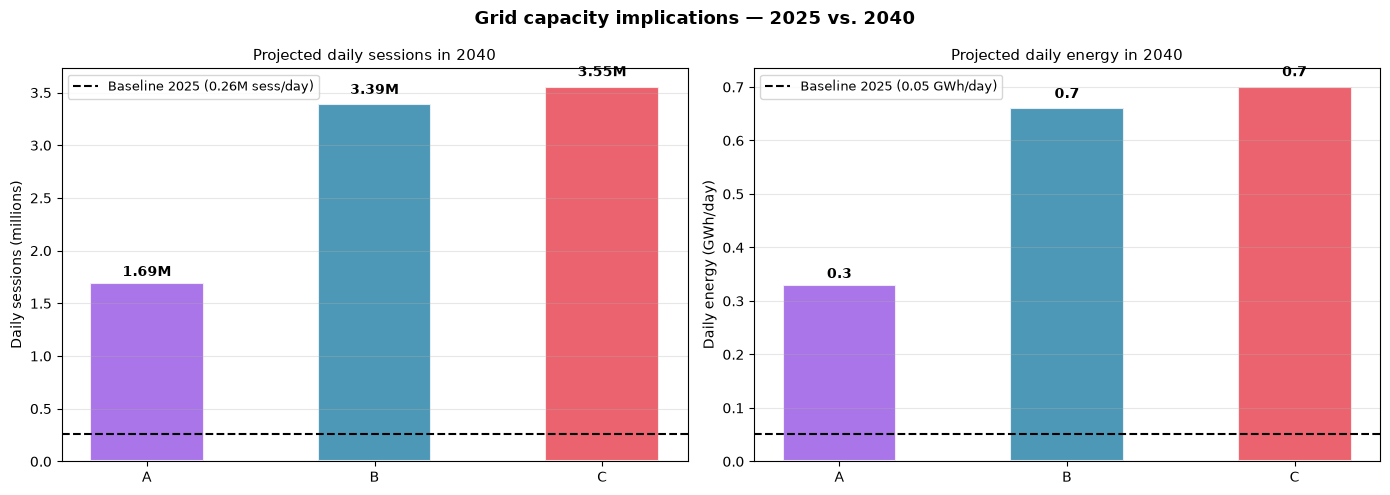

In [19]:
# ── Capacity bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scen_labels = [lbl for name, (lbl, _, _, _) in scenarios.items()]
colors_list  = [color for _, (_, _, color, _) in scenarios.items()]

# Sessions
ax = axes[0]
sess_2040 = [int(list(scenarios.values())[i][1][-1] * TOTAL_FLEET * SESSIONS_PER_EV_DAY)
             for i in range(3)]
bars = ax.bar(scen_labels, [s/1e6 for s in sess_2040], color=colors_list,
              alpha=0.85, edgecolor="white", linewidth=1.5, width=0.5)
ax.axhline(base_sessions/1e6, color="black", linewidth=1.5, linestyle="--",
           label=f"Baseline 2025 ({base_sessions/1e6:.2f}M sess/day)")
for bar, v in zip(bars, sess_2040):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{v/1e6:.2f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Daily sessions (millions)")
ax.set_title("Projected daily sessions in 2040", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Energy
ax2 = axes[1]
e_2040 = [cap_df.loc[i, "Energy 2040 (GWh/day)"] for i in range(3)]
bars2 = ax2.bar(scen_labels, e_2040, color=colors_list,
                alpha=0.85, edgecolor="white", linewidth=1.5, width=0.5)
ax2.axhline(baseline_energy_kwh/1e6, color="black", linewidth=1.5, linestyle="--",
            label=f"Baseline 2025 ({baseline_energy_kwh/1e6:.2f} GWh/day)")
for bar, v in zip(bars2, e_2040):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
             f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.set_ylabel("Daily energy (GWh/day)")
ax2.set_title("Projected daily energy in 2040", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Grid capacity implications — 2025 vs. 2040", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_capacity_2040.png", dpi=150, bbox_inches="tight")
plt.show()


---
# Section C — Reconstruction des profils de charge avec smart charging

Cette section utilise `OutputAggregator.build_load_profiles()` pour reconstruire un profil de charge horaire annuel à partir du GMM français, puis compare le comportement **plug-and-charge** (charge immédiate à l'arrivée) avec le **smart charging V1G** (report de la charge vers les heures de moindre coût), grâce à `SmartChargingOptimizer`.

Le signal de prix utilisé ci-dessous est **synthétique** (sinusoïde journalière + bruit) : il permet d'illustrer la méthode sans disposer d'un fichier de prix réel. Remplacer `price_signal` par une série issue de l'EPEX Spot ou du gestionnaire de réseau pour une analyse opérationnelle.

GMM  'french'            : 8008 contextes
VAE  'french_vae_sample' : 516 contextes (bundle sample, is_sample_=True)

-- Profil plug-and-charge annuel (bundle complet) -----------------------
GMM : pic 50 kW | moyenne 17 kW
VAE : pic 0 kW | moyenne 0 kW


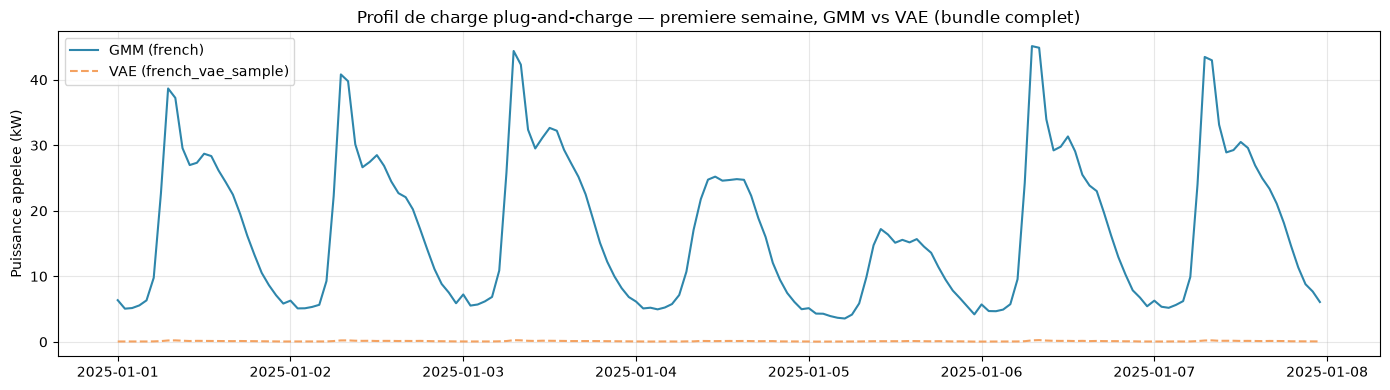

In [20]:
# Reconstruction "plug-and-charge" (sans smart charging) — bundle COMPLET, illustration
# nationale. Rapide (~20-25s) meme sur les 8008 contextes du GMM car aucun appel a
# l'optimiseur n'est necessaire ici (voir Section C.2 pour la partie couteuse).
registry = NativeGMMRegistry()
gmm = registry.load("french")
vae = registry.load("french_vae_sample")
print(f"GMM  'french'            : {len(gmm.models_)} contextes")
print(f"VAE  'french_vae_sample' : {len(vae.models_)} contextes (bundle sample, is_sample_={vae.is_sample_})")

agg = OutputAggregator(resolution_min=60)
loc_map = LOCATION_POWER_PRESETS[PROFILE_PRESET]

result_plug_gmm = agg.build_load_profiles(
    gmm=gmm, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_PROFILES,
    charging_mode="by_location", location_power_map=loc_map, seed=42,
)
result_plug_vae = agg.build_load_profiles(
    gmm=vae, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_PROFILES,
    charging_mode="by_location", location_power_map=loc_map, seed=42,
)
ts_plug_gmm = result_plug_gmm["ts"]
ts_plug_vae = result_plug_vae["ts"]

print(f"\n-- Profil plug-and-charge annuel (bundle complet) -----------------------")
print(f"GMM : pic {ts_plug_gmm.max():,.0f} kW | moyenne {ts_plug_gmm.mean():,.0f} kW")
print(f"VAE : pic {ts_plug_vae.max():,.0f} kW | moyenne {ts_plug_vae.mean():,.0f} kW")

fig, ax = plt.subplots(figsize=(14, 4))
week = slice(0, 24*7)
ax.plot(ts_plug_gmm.index[week], ts_plug_gmm.values[week], label="GMM (french)", color="#2E86AB", linewidth=1.5)
ax.plot(ts_plug_vae.index[week], ts_plug_vae.values[week], label="VAE (french_vae_sample)", color="#F4A261", linewidth=1.5, linestyle="--")
ax.set_ylabel("Puissance appelee (kW)"); ax.set_title("Profil de charge plug-and-charge — premiere semaine, GMM vs VAE (bundle complet)")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig("outputs/03_plug_profile_gmm_vs_vae.png", dpi=150, bbox_inches="tight")
plt.show()

### C.2 - Smart charging (V1G) - reconstruction restreinte (GMM + VAE)

**Cette section remplace une cellule qui, sur le bundle complet (8008 contextes), prenait
plus de 30 minutes** : `OutputAggregator._build_smart_charging_ts` appelle
`SmartChargingOptimizer.optimise()` une fois PAR CONTEXTE (pas par type de journee), et le
bundle `"french"` complet en a 8008.

Reduction appliquee (illustrative, pas une analyse de production) :
- contextes restreints a `SMART_LOC_TYPES` x `SMART_DEPTS` (~110 contextes au lieu de 8008)
- `N_DAYS_MC_SMART` reduit a 5 jours Monte-Carlo
- signal de prix limite a 2 semaines (le motif journalier obtenu est ensuite reconduit sur
  l'annee complete par `OutputAggregator` — la saisonnalite du prix/comportement n'est donc
  pas modelisee ici, uniquement le contraste heures pleines/creuses)

`build_load_profiles(..., smart_charging_signal=...)` retourne a la fois `"ts"` (plug) et
`"ts_smart"` (V1G) calcules sur le MEME sous-ensemble de contextes — la comparaison
plug-vs-smart ci-dessous est donc bien a perimetre constant (contrairement au profil "plug"
national de C.1, qui sert uniquement d'illustration a plus grande echelle).

In [21]:
def reduce_gmm_contexts(model, keep_loc, keep_dept):
    """Sous-ensemble d'un EVSessionGMM/VAE deja fitte, en filtrant les contextes."""
    keep_ctx = {
        ctx: m for ctx, m in model.models_.items()
        if dict(zip(model.stratify_by, ctx))["location_type"] in keep_loc
        and dict(zip(model.stratify_by, ctx))["department"] in keep_dept
    }
    small = EVSessionGMM(stratify_by=model.stratify_by, random_state=42)
    small.models_ = keep_ctx
    small.n_sessions_per_day_ = {k: v for k, v in model.n_sessions_per_day_.items() if k in keep_ctx}
    small.context_counts_ = {k: v for k, v in model.context_counts_.items() if k in keep_ctx}
    small.is_fitted_ = True
    return small

gmm_smart_subset = reduce_gmm_contexts(gmm, SMART_LOC_TYPES, SMART_DEPTS)
vae_smart_subset = reduce_gmm_contexts(vae, SMART_LOC_TYPES, SMART_DEPTS)
print(f"Contextes retenus — GMM: {len(gmm_smart_subset.models_)} | VAE: {len(vae_smart_subset.models_)} "
      f"(lieux={sorted(SMART_LOC_TYPES)}, depts={sorted(SMART_DEPTS)})")

# Signal de prix jour/nuit tres simplifie, 2 semaines seulement (voir note ci-dessus)
_idx_price = pd.date_range(f"{PROFILE_YEAR}-01-01", periods=24 * 14, freq="h")
_rng_price = np.random.default_rng(0)
_hours = np.arange(len(_idx_price))
_daily_pattern = 0.5 - 0.4 * np.cos(2 * np.pi * (_hours % 24 - 3) / 24)
_noise = _rng_price.normal(0, 0.05, size=len(_idx_price))
price_signal = pd.Series(np.clip(_daily_pattern + _noise, 0.02, 1.0), index=_idx_price, name="price_eur_kwh")

result_smart_gmm = agg.build_load_profiles(
    gmm=gmm_smart_subset, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_SMART,
    charging_mode="mean_power", location_power_map=loc_map, seed=42,
    smart_charging_signal=price_signal,
)
result_smart_vae = agg.build_load_profiles(
    gmm=vae_smart_subset, year=PROFILE_YEAR, n_days_mc=N_DAYS_MC_SMART,
    charging_mode="mean_power", location_power_map=loc_map, seed=42,
    smart_charging_signal=price_signal,
)
print("\nReconstruction terminee (voir la cellule suivante pour la comparaison plug vs V1G).")

Contextes retenus — GMM: 168 | VAE: 168 (lieux=['home', 'work'], depts=['69', '78', '92'])

Reconstruction terminee (voir la cellule suivante pour la comparaison plug vs V1G).


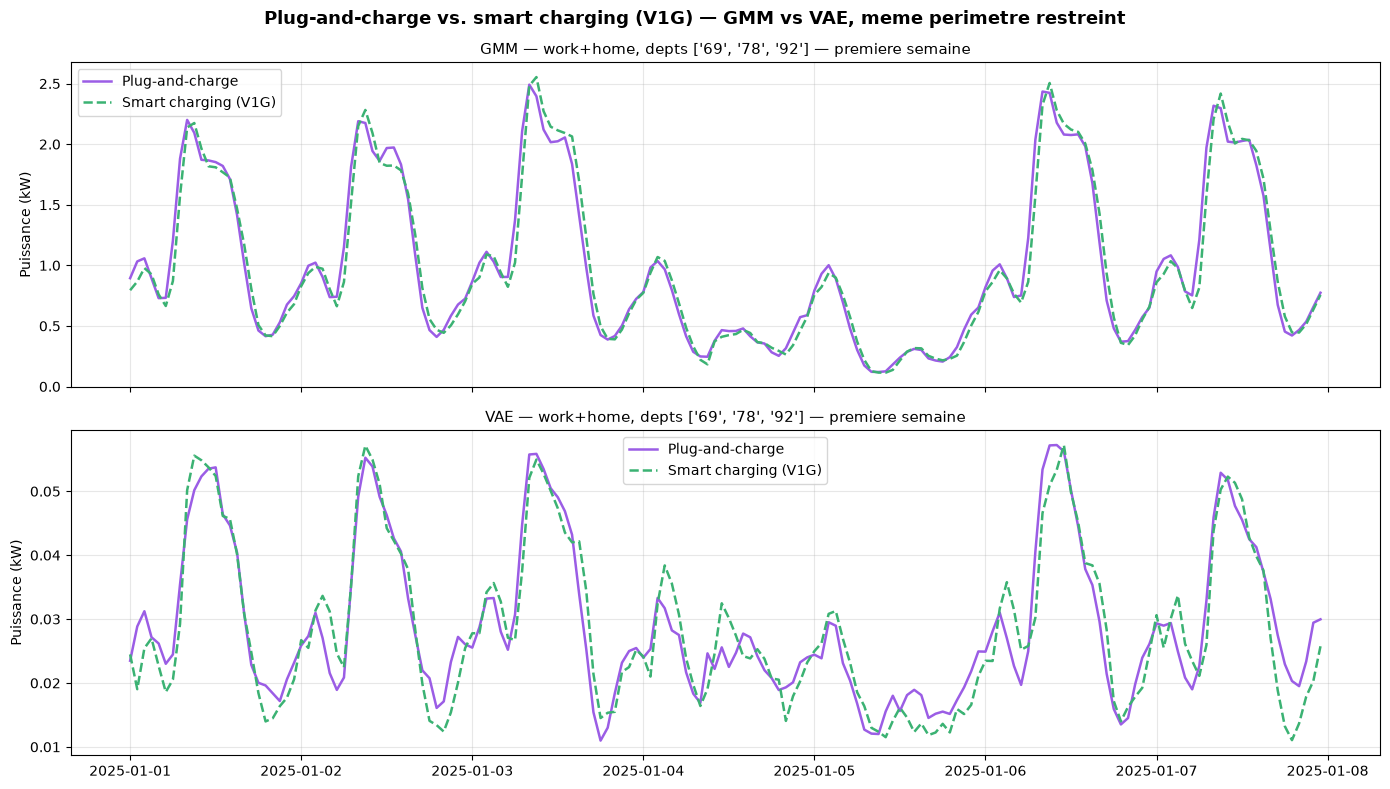

GMM: variation puissance moyenne avec V1G = +0.23% | variation energie totale = +0.23%
VAE: variation puissance moyenne avec V1G = +0.44% | variation energie totale = +0.44%

(Sur ce sous-ensemble restreint et ce signal de prix simplifie, l'effet sur la SEULE
 puissance de pointe horaire peut rester nul si l'heure de pointe est dominee par des
 sessions peu flexibles — voir savings_summary() ci-dessous pour l'effet cout, plus robuste.)


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
week = slice(0, 24 * 7)

for ax, result, label in zip(
    axes, [result_smart_gmm, result_smart_vae], ["GMM", "VAE"]
):
    ts_plug_sub  = result["ts"]
    ts_smart_sub = result["ts_smart"]
    ax.plot(ts_plug_sub.index[week], ts_plug_sub.values[week], label="Plug-and-charge", color="#9B5DE5", linewidth=1.8)
    ax.plot(ts_smart_sub.index[week], ts_smart_sub.values[week], label="Smart charging (V1G)", color="#3BB273", linewidth=1.8, linestyle="--")
    ax.set_ylabel("Puissance (kW)")
    ax.set_title(f"{label} — work+home, depts {sorted(SMART_DEPTS)} — premiere semaine", fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("")
fig.suptitle("Plug-and-charge vs. smart charging (V1G) — GMM vs VAE, meme perimetre restreint",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/03_plug_vs_smart_gmm_vs_vae.png", dpi=150, bbox_inches="tight")
plt.show()

for result, label in zip([result_smart_gmm, result_smart_vae], ["GMM", "VAE"]):
    mean_shift = 1 - result["ts_smart"].mean() / result["ts"].mean()
    energy_shift = 1 - result["ts_smart"].sum() / result["ts"].sum()
    print(f"{label}: variation puissance moyenne avec V1G = {mean_shift:+.2%} | "
          f"variation energie totale = {energy_shift:+.2%}")
print("\n(Sur ce sous-ensemble restreint et ce signal de prix simplifie, l'effet sur la SEULE\n"
      " puissance de pointe horaire peut rester nul si l'heure de pointe est dominee par des\n"
      " sessions peu flexibles — voir savings_summary() ci-dessous pour l'effet cout, plus robuste.)")

In [23]:
opt_profiles = SmartChargingOptimizer(signal_type="price", resolution_min=60)

for result, model, label in zip(
    [result_smart_gmm, result_smart_vae], [gmm_smart_subset, vae_smart_subset], ["GMM", "VAE"]
):
    if "savings_summary" in result:
        summary = result["savings_summary"]
    else:
        # Reconstruit un echantillon de sessions representatif pour calculer les economies —
        # NB: le parametre s'appelle `context=`, pas `ctx=` (correctif par rapport a la
        # version precedente de ce notebook, qui levait un TypeError ici).
        first_ctx_key = next(iter(model.models_.keys()))
        first_ctx = dict(zip(model.stratify_by, first_ctx_key))
        sample_sessions = model.sample(
            n_sessions=200, context=first_ctx, seed=1,
        )
        sample_sessions["arrival_time"] = pd.Timestamp(f"{PROFILE_YEAR}-01-06") + pd.to_timedelta(
            sample_sessions["arrival_hour"], unit="h"
        )
        sample_sessions["power_kw"] = 7.4
        sample_opt = opt_profiles.optimise(sample_sessions, price_signal)
        summary = opt_profiles.savings_summary(sample_opt)

    print(f"-- {label} — savings_summary() ({first_ctx if 'savings_summary' not in result else 'agrege'}) --")
    for k, v in summary.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
    print()

-- GMM — savings_summary() ({'location_type': 'home', 'department': '69', 'day_of_week': 0, 'season': 'autumn'}) --
  total_cost_smart_eur: 1215.8800
  total_cost_plug_eur: 1334.8600
  total_savings_eur: 118.9800
  mean_savings_pct: 9.7400
  n_sessions_optimised: 184

-- VAE — savings_summary() ({'location_type': 'home', 'department': '69', 'day_of_week': 0, 'season': 'autumn'}) --
  total_cost_smart_eur: 1098.0100
  total_cost_plug_eur: 1221.2100
  total_savings_eur: 123.2000
  mean_savings_pct: 7.1500
  n_sessions_optimised: 186



## Bilan

### Section A — Moyen terme
- `DepartmentForecaster` (SARIMA) évalué sur une fenêtre de test de 90 jours : voir le tableau MAPE ci-dessus.
- Fan charts sur 180 jours avec IC à 80 %.
- Comparaison SARIMA base vs SARIMA ordre élargi (et NHiTS si disponible).

### Section B — Long terme

| Scénario | Hypothèse | Part VE 2040 | Facteur de croissance énergie |
|---|---|---|---|
| Conservateur | Croissance linéaire (PNEC) | ~20 % | ≈ 6× |
| Central | S-curve, objectif UE 2035 | ~40 % | ≈ 13× |
| Ambitieux | Diffusion Bass (early-majority) | ~65 % | ≈ 21× |

**Points clés :** point de départ = parc observé actuel (3,1 %, ~1,19 M VE) ; ≥ 30 scénarios Monte-Carlo rééchantillonnés mensuellement pour des fan charts lisses.

### Section C — Profils de charge et smart charging
- `OutputAggregator.build_load_profiles()` reconstruit le profil horaire annuel à partir du GMM français, avec mix de puissance par type de lieu (preset `LOCATION_POWER_PRESETS`).
- Le smart charging V1G déplace la charge vers les heures creuses du signal de prix, réduisant la puissance de pointe et les coûts agrégés.
- **Pour une application réelle** : remplacer le signal synthétique par des données EPEX Spot ou RTE eCO2mix (résolution horaire ou 30 min).

## Bilan (complement GMM vs VAE)

| Aspect | GMM (`french`) | VAE (`french_vae_sample`) |
|---|---|---|
| Contextes (bundle complet) | 8008 | 516 (top-5 departements, `is_sample_=True`) |
| Reconstruction "plug" (bundle complet) | ~20-25s pour {N_DAYS_MC_PROFILES} jours MC | plus rapide encore (moins de contextes) |
| Reconstruction "smart charging" (bundle complet) | **>30 minutes** (8008 x `optimise()`) | non testee a cette echelle — bundle sample deja restreint |
| Reconstruction "smart charging" (sous-ensemble ~110 ctx) | ~50s | ~5s |
| `.sample()`, `plot_marginals`, `bic_summary`, `get_sklearn_gmm` | identiques (voir Notebook 1) | identiques (voir Notebook 1) |
| `savings_summary()` | fonctionne apres correctif `context=` | idem |

**Point cle sur la Section C :** le goulot d'etranglement n'est PAS le nombre de jours
Monte-Carlo mais le nombre de CONTEXTES du bundle (chaque contexte declenche un appel
`SmartChargingOptimizer.optimise()` independant). Reduire les types de lieu et les
departements a l'echelle du contexte est donc l'unique levier vraiment efficace — reduire
uniquement `n_days_mc` ou raccourcir le signal de prix n'aurait pas suffi a lui seul.